# Project — Credit Risk Scoring

**Domain:** Finance / Banking  
**Type:** Machine Learning — Classification, Fairness and Temporal Generalization  
**Primary objective:** Predict the probability that a loan applicant will default.

A bank must decide whether to approve loan applications. A useful credit-scoring model must achieve good predictive performance, remain interpretable, avoid unjustified demographic disparities, generalize to later populations and reflect the fact that approving a bad loan is more costly than rejecting a good borrower.

### Target definition

- `0 = good credit / no default`
- `1 = bad credit / default`


## Notebook — Four Required Sections

1. **EDA** — structure, quality, distributions, class balance and key patterns.
2. **Modeling** — preprocessing, model selection, cross-validation, comparison table and final evaluation.
3. **Research Direction** — temporal generalization, fairness, interpretability and asymmetric error cost.
4. **Conclusions** — project-specific conclusions with calculated numbers and conclusion areas.


### Why Cross-Validation?

Cross-validation provides a more reliable estimate of model performance than a single validation split. Each training observation is used for both training and validation across different folds, while stratification preserves the proportion of good-credit and default cases.

The same folds and evaluation metrics are used for all models, which makes the comparison more consistent and fair.


## Research questions

- How does default rate vary by age, sex and loan purpose?
- Is the target class balanced enough for accuracy to be meaningful?
- Which classical model performs best on a small tabular dataset?
- Does a neural network underperform classical models on only 1,000 observations?
- How much performance is lost when the model is evaluated on data collected decades later?
- Are approval and error rates similar across demographic groups?
- How does a higher cost for approving a bad loan change the optimal decision threshold?


## Dataset setup

This notebook reads both official UCI datasets from the local project folders below:

```text
C:\PROJECT DATA SCIENCE\CreditRisk.ML\statlog+german+credit+data
C:\PROJECT DATA SCIENCE\CreditRisk.ML\south+german+credit+update
```


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
from pathlib import Path
import sys
import platform

PROJECT_ROOT = Path(r"C:\PROJECT DATA SCIENCE\CreditRisk.ML")
GERMAN_DATA_ROOT = Path(r"C:\PROJECT DATA SCIENCE\CreditRisk.ML\statlog+german+credit+data")
SOUTH_GERMAN_DATA_ROOT = Path(r"C:\PROJECT DATA SCIENCE\CreditRisk.ML\south+german+credit+update")

print("=" * 72)
print("PROJECT ENVIRONMENT CHECK")
print("=" * 72)
print("Python version:", sys.version.split()[0])
print("Operating system:", platform.platform())
print("Project folder exists:", PROJECT_ROOT.exists())
print("German data folder exists:", GERMAN_DATA_ROOT.exists())
print("South German data folder exists:", SOUTH_GERMAN_DATA_ROOT.exists())
print("Working directory:", Path.cwd())

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root does not exist: {PROJECT_ROOT}"
    )

if not GERMAN_DATA_ROOT.exists():
    raise FileNotFoundError(
        f"German Credit folder does not exist: {GERMAN_DATA_ROOT}"
    )

if not SOUTH_GERMAN_DATA_ROOT.exists():
    raise FileNotFoundError(
        f"South German Credit folder does not exist: {SOUTH_GERMAN_DATA_ROOT}"
    )

print("\nEnvironment validation completed successfully.")


PROJECT ENVIRONMENT CHECK
Python version: 3.14.3
Operating system: Windows-11-10.0.26200-SP0
Project folder exists: True
German data folder exists: True
South German data folder exists: True
Working directory: c:\PROJECT DATA SCIENCE\CreditRisk.ML

Environment validation completed successfully.


**Code explanation:** This cell imports the required libraries, fixes the random seed and configures display settings for reproducible work.


# Section 1 — EDA

## 1.1 Load the German Credit dataset

The original German Credit dataset contains 1,000 applicants and 20 predictors.  
Its original target uses:

- `1 = good credit`
- `2 = bad credit`

For this project the target is converted to:

- `0 = good / non-default`
- `1 = bad / default`

This makes the positive class equal to the event the bank wants to detect.


In [3]:
import io
import zipfile
from pathlib import Path

# -------------------------------------------------------------------
# LOCAL DATA — GERMAN CREDIT DATASET
# -------------------------------------------------------------------
GERMAN_DATA_ROOT = Path(r"C:\PROJECT DATA SCIENCE\CreditRisk.ML\statlog+german+credit+data")

if not GERMAN_DATA_ROOT.exists():
    raise FileNotFoundError(
        "German Credit folder was not found:\n"
        f"{GERMAN_DATA_ROOT}\n\n"
        "Check that the folder name and drive location are correct."
    )

# Search recursively for either the official ZIP archive or german.data.
german_zip_candidates = list(
    GERMAN_DATA_ROOT.rglob("statlog+german+credit+data.zip")
)
german_data_candidates = list(
    GERMAN_DATA_ROOT.rglob("german.data")
)

if german_zip_candidates:
    GERMAN_SOURCE_PATH = german_zip_candidates[0]

    with zipfile.ZipFile(GERMAN_SOURCE_PATH, "r") as archive:
        archive_files = archive.namelist()

        if "german.data" not in archive_files:
            raise FileNotFoundError(
                "'german.data' was not found inside the German Credit ZIP archive."
            )

        german_raw = archive.read("german.data")

    german_df = pd.read_csv(
        io.BytesIO(german_raw),
        sep=r"\s+",
        header=None
    )

elif german_data_candidates:
    GERMAN_SOURCE_PATH = german_data_candidates[0]

    german_df = pd.read_csv(
        GERMAN_SOURCE_PATH,
        sep=r"\s+",
        header=None
    )

else:
    searched_files = "\n".join(
        f" - {path.name}" for path in GERMAN_DATA_ROOT.rglob("*")
        if path.is_file()
    )

    raise FileNotFoundError(
        "Neither the German Credit ZIP archive nor 'german.data' was found.\n\n"
        f"Folder searched:\n{GERMAN_DATA_ROOT}\n\n"
        f"Files found:\n{searched_files or ' - No files found'}"
    )

print("German Credit source:")
print(GERMAN_SOURCE_PATH.resolve())
print("\nGerman Credit raw shape:", german_df.shape)

display(german_df.head())


German Credit source:
C:\PROJECT DATA SCIENCE\CreditRisk.ML\statlog+german+credit+data\german.data

German Credit raw shape: (1000, 21)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


## 1.2 Standardize feature names and historical category codes

The two datasets describe the same 20 variables, but their column names and encodings can differ.  
To make the temporal test meaningful, the German categorical codes (`A11`, `A12`, etc.) are converted to the corresponding numeric category levels used by the South German dataset.

The feature order follows the official German Credit specification.


In [4]:
FEATURE_NAMES = [
    "checking_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment_duration",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_duration",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker"
]

GERMAN_CODE_MAPS = {
    "checking_status": {"A11": 1, "A12": 2, "A13": 3, "A14": 4},
    "credit_history": {"A30": 0, "A31": 1, "A32": 2, "A33": 3, "A34": 4},
    "purpose": {
        "A40": 0, "A41": 1, "A42": 2, "A43": 3, "A44": 4,
        "A45": 5, "A46": 6, "A47": 7, "A48": 8, "A49": 9,
        "A410": 10
    },
    "savings": {"A61": 1, "A62": 2, "A63": 3, "A64": 4, "A65": 5},
    "employment_duration": {"A71": 1, "A72": 2, "A73": 3, "A74": 4, "A75": 5},
    "personal_status_sex": {"A91": 1, "A92": 2, "A93": 3, "A94": 4, "A95": 5},
    "other_debtors": {"A101": 1, "A102": 2, "A103": 3},
    "property": {"A121": 1, "A122": 2, "A123": 3, "A124": 4},
    "other_installment_plans": {"A141": 1, "A142": 2, "A143": 3},
    "housing": {"A151": 1, "A152": 2, "A153": 3},
    "job": {"A171": 1, "A172": 2, "A173": 3, "A174": 4},
    "telephone": {"A191": 1, "A192": 2},
    "foreign_worker": {"A201": 1, "A202": 2}
}

if german_df.shape[1] != 21:
    raise ValueError(
        "German Credit must contain exactly 21 columns "
        "(20 features + 1 target). "
        f"Current shape: {german_df.shape}"
    )

X_raw = german_df.iloc[:, :20].copy()
y_raw = german_df.iloc[:, 20].copy()

X_raw.columns = FEATURE_NAMES
X = X_raw.copy()

for column, mapping in GERMAN_CODE_MAPS.items():
    X[column] = X[column].map(mapping)

for column in FEATURE_NAMES:
    X[column] = pd.to_numeric(X[column], errors="coerce")

if X.isna().any().any():
    raise ValueError(
        "German Credit contains missing or unmapped feature values."
    )

y_raw = pd.to_numeric(y_raw, errors="coerce")

if y_raw.isna().any():
    raise ValueError(
        "German Credit target contains non-numeric or missing values."
    )

# German Credit target:
# 1 = good credit -> 0 = no default
# 2 = bad credit  -> 1 = default
y = (y_raw == 2).astype(int)
y.name = "default"

print("German Credit prepared shape:", X.shape)
print("Target shape:", y.shape)
print("Missing feature values:", int(X.isna().sum().sum()))
print("Default rate:", f"{y.mean():.1%}")

display(X.head())
display(
    y.value_counts()
     .sort_index()
     .rename(index={0: "Good / no default", 1: "Bad / default"})
)

German Credit prepared shape: (1000, 20)
Target shape: (1000,)
Missing feature values: 0
Default rate: 30.0%


,checking_status,duration_months,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,residence_duration,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker
0,1,6,4,3,1169,5,5,4,3,1,4,1,67,3,2,2,3,1,2,1
1,2,48,2,3,5951,1,3,2,2,1,2,1,22,3,2,1,3,1,1,1
2,4,12,4,6,2096,1,4,2,3,1,3,1,49,3,2,1,2,2,1,1
3,1,42,2,2,7882,1,4,2,3,3,4,2,45,3,3,1,3,2,1,1
4,1,24,3,0,4870,1,3,3,3,1,4,4,53,3,3,2,3,2,1,1


default
Good / no default    700
Bad / default        300
Name: count, dtype: int64

## 1.3 Data quality checks


In [5]:
quality_table = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "unique_values": X.nunique(),
    "minimum": X.min(),
    "maximum": X.max()
})

display(quality_table)
print("Duplicate rows:", X.duplicated().sum())

,dtype,missing,unique_values,minimum,maximum
checking_status,int64,0,4,1,4
duration_months,int64,0,33,4,72
credit_history,int64,0,5,0,4
purpose,int64,0,10,0,10
credit_amount,int64,0,921,250,18424
savings,int64,0,5,1,5
employment_duration,int64,0,5,1,5
installment_rate,int64,0,4,1,4
personal_status_sex,int64,0,4,1,4
other_debtors,int64,0,3,1,3


Duplicate rows: 0


## 1.4 Class balance

The dataset contains approximately 70% good-credit and 30% bad-credit applicants.

This is a **moderate imbalance**. Accuracy is still useful, but it is not sufficient by itself.  
The project therefore emphasizes:

- **F1 score** for the default class
- **Recall** for detecting defaults
- **ROC-AUC** for probability ranking
- **Confusion matrix** for business interpretation


,count,share
default,,
Good / no default,700,0.7000
Bad / default,300,0.3000


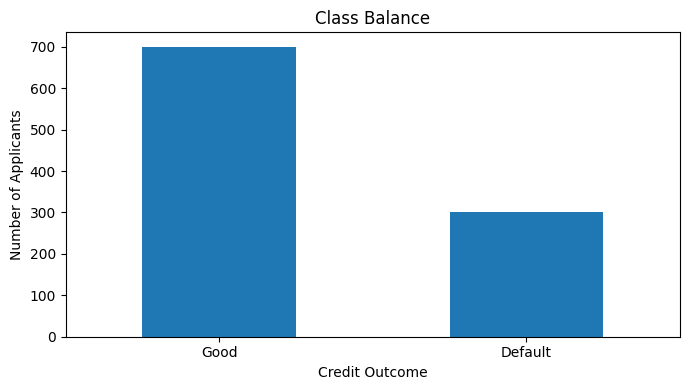

In [6]:
class_counts = y.value_counts().sort_index()
class_rates = y.value_counts(normalize=True).sort_index()

class_balance = pd.DataFrame({
    "count": class_counts,
    "share": class_rates
}).rename(index={0: "Good / no default", 1: "Bad / default"})

display(class_balance)

plt.figure(figsize=(7, 4))
class_counts.rename(index={0: "Good", 1: "Default"}).plot(kind="bar")
plt.title("Class Balance")
plt.xlabel("Credit Outcome")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1.5 Create interpretable demographic labels

The original `personal_status_sex` feature combines sex and marital status.  
According to the German Credit codebook:

- Codes `2` and `5` represent female applicants.
- Codes `1`, `3` and `4` represent male applicants.

The model keeps the original encoded predictor, while a separate `sex_group` variable is used for fairness analysis.


In [7]:
eda = X.copy()
eda["default"] = y.values
eda["sex_group"] = np.where(
    eda["personal_status_sex"].isin([2, 5]),
    "Female",
    "Male"
)

eda["age_group"] = pd.cut(
    eda["age"],
    bins=[0, 24, 34, 49, np.inf],
    labels=["Under 25", "25–34", "35–49", "50+"],
    right=True
)

PURPOSE_LABELS = {
    0: "Car (new)",
    1: "Car (used)",
    2: "Furniture/equipment",
    3: "Radio/TV",
    4: "Domestic appliances",
    5: "Repairs",
    6: "Education",
    7: "Vacation/other",
    8: "Retraining",
    9: "Business",
    10: "Other"
}
eda["purpose_label"] = eda["purpose"].map(PURPOSE_LABELS).fillna("Unknown")

display(eda[["age", "age_group", "personal_status_sex", "sex_group", "purpose_label", "default"]].head())

,age,age_group,personal_status_sex,sex_group,purpose_label,default
0,67,50+,3,Male,Radio/TV,0
1,22,Under 25,2,Female,Radio/TV,1
2,49,35–49,3,Male,Education,0
3,45,35–49,3,Male,Furniture/equipment,0
4,53,50+,3,Male,Car (new),1


**Code explanation:** This cell creates readable demographic and purpose labels for EDA and fairness reporting.


## 1.6 Default rate by age group


,count,default_rate
age_group,,
Under 25,149,0.4094
25–34,399,0.3283
35–49,327,0.2263
50+,125,0.2720


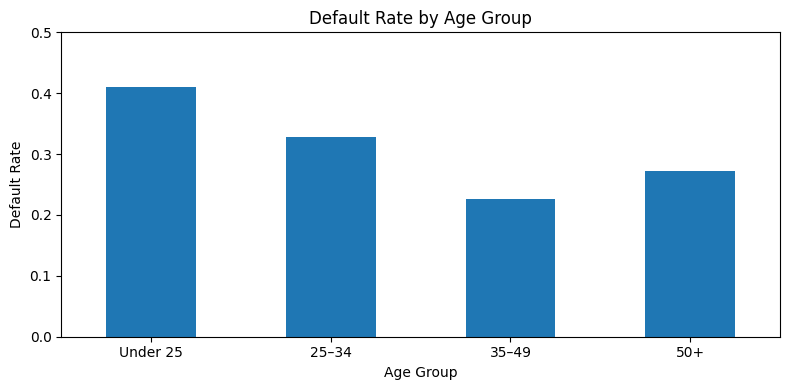

In [8]:
default_by_age = (
    eda.groupby("age_group", observed=False)["default"]
       .agg(["count", "mean"])
       .rename(columns={"mean": "default_rate"})
)

display(default_by_age)

plt.figure(figsize=(8, 4))
default_by_age["default_rate"].plot(kind="bar")
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.ylim(0, max(0.5, default_by_age["default_rate"].max() + 0.05))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Code explanation:** This cell calculates and plots default rates across age groups.


## 1.7 Default rate by sex


,count,default_rate
sex_group,,
Female,310,0.3516
Male,690,0.2768


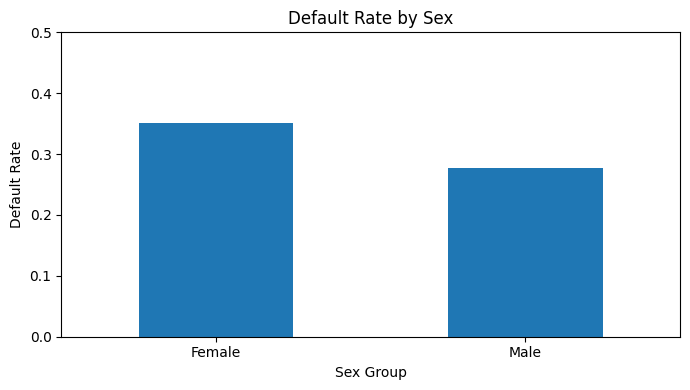

In [9]:
default_by_sex = (
    eda.groupby("sex_group")["default"]
       .agg(["count", "mean"])
       .rename(columns={"mean": "default_rate"})
)

display(default_by_sex)

plt.figure(figsize=(7, 4))
default_by_sex["default_rate"].plot(kind="bar")
plt.title("Default Rate by Sex")
plt.xlabel("Sex Group")
plt.ylabel("Default Rate")
plt.ylim(0, max(0.5, default_by_sex["default_rate"].max() + 0.05))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Code explanation:** This cell calculates and plots default rates across sex groups.


## 1.8 Default rate by loan purpose


,count,default_rate
purpose_label,,
Education,50,0.4400
Other,12,0.4167
Car (new),234,0.3803
Repairs,22,0.3636
Business,97,0.3505
Domestic appliances,12,0.3333
Furniture/equipment,181,0.3204
Radio/TV,280,0.2214
Car (used),103,0.1650


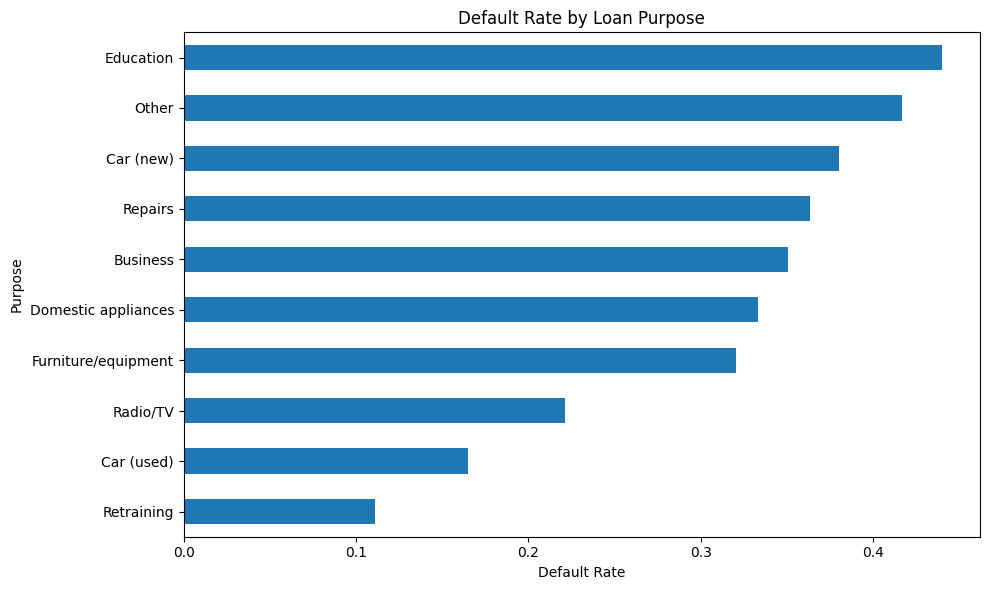

In [10]:
default_by_purpose = (
    eda.groupby("purpose_label")["default"]
       .agg(["count", "mean"])
       .rename(columns={"mean": "default_rate"})
       .sort_values("default_rate", ascending=False)
)

display(default_by_purpose)

plt.figure(figsize=(10, 6))
default_by_purpose["default_rate"].sort_values().plot(kind="barh")
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate")
plt.ylabel("Purpose")
plt.tight_layout()
plt.show()

**Code explanation:** This cell ranks and visualizes default rates across loan purposes.


## 1.9 Feature distributions

Credit amount, loan duration and age are examined because they have direct business meaning and are frequently important in credit-risk models.


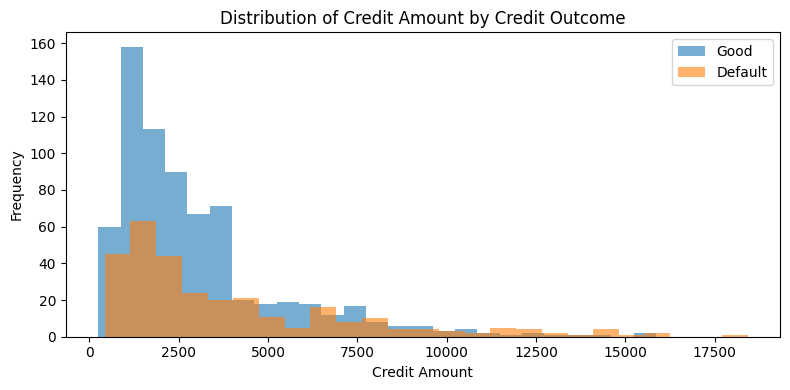

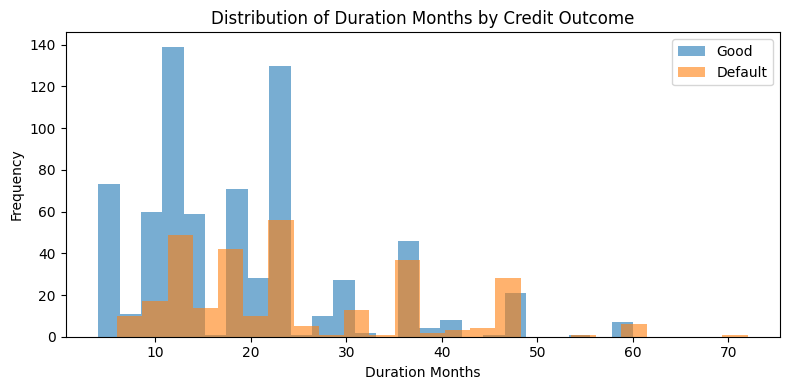

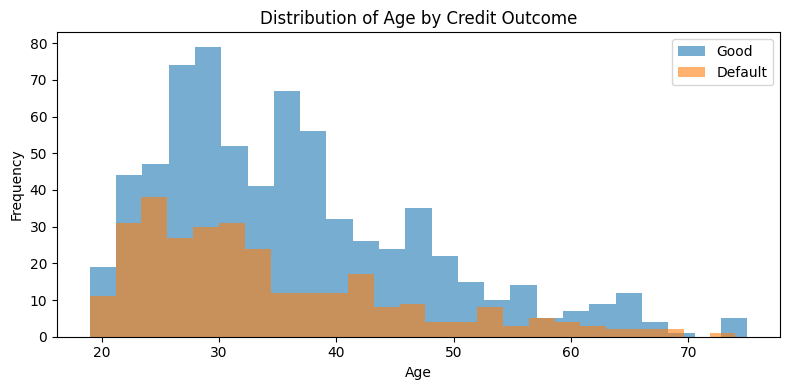

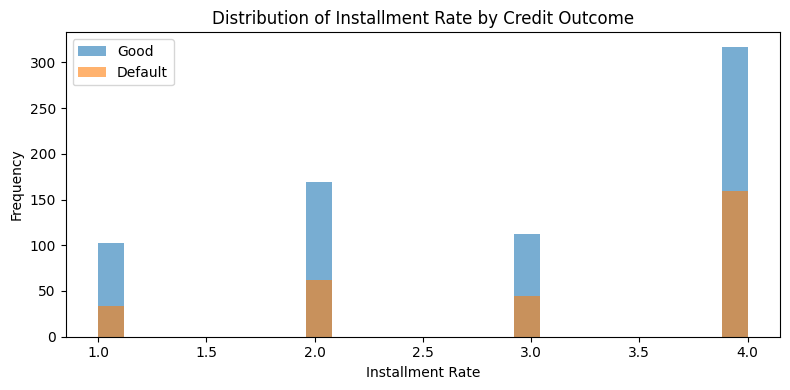

In [11]:
numeric_features_to_plot = ["credit_amount", "duration_months", "age", "installment_rate"]

for feature in numeric_features_to_plot:
    plt.figure(figsize=(8, 4))
    for target_value, label in [(0, "Good"), (1, "Default")]:
        subset = eda.loc[eda["default"] == target_value, feature].dropna()
        plt.hist(subset, bins=25, alpha=0.6, label=label)
    plt.title(f"Distribution of {feature.replace('_', ' ').title()} by Credit Outcome")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Code explanation:** This cell compares important feature distributions for good-credit and default cases.


## Section 1 findings

The following code generates a concise EDA summary from the actual dataset.


In [12]:
overall_default_rate = y.mean()
highest_age_group = default_by_age["default_rate"].idxmax()
highest_purpose = default_by_purpose["default_rate"].idxmax()

print(f"Overall default rate: {overall_default_rate:.1%}")
print(f"Age group with the highest observed default rate: {highest_age_group}")
print(f"Purpose with the highest observed default rate: {highest_purpose}")
print()
print(
    "Implication: because the default class is smaller than the good-credit class, "
    "model selection should not be based on accuracy alone. F1, recall, AUC and "
    "the confusion matrix are required."
)

Overall default rate: 30.0%
Age group with the highest observed default rate: Under 25
Purpose with the highest observed default rate: Education

Implication: because the default class is smaller than the good-credit class, model selection should not be based on accuracy alone. F1, recall, AUC and the confusion matrix are required.


**Code explanation:** This cell calculates and plots default rates across age groups.


# Section 2 — Modeling

## 2.1 Train/test split

A stratified 80/20 split preserves the 70/30 target ratio in both subsets.

The test set is kept separate from cross-validation and is used only after model selection.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training default rate:", f"{y_train.mean():.1%}")
print("Test default rate:", f"{y_test.mean():.1%}")

Training shape: (800, 20)
Test shape: (200, 20)
Training default rate: 30.0%
Test default rate: 30.0%


**Code explanation:** This cell creates a stratified training and test split so both sets preserve the target distribution.


## 2.2 Preprocessing pipeline

All 20 variables are represented numerically after harmonization.

The preprocessing pipeline contains:

1. **Median imputation** for robustness to missing values.
2. **StandardScaler** so Logistic Regression and the Neural Network receive comparable feature scales.

Tree-based models do not require scaling, but using the same preprocessing structure keeps the comparison consistent and prevents data leakage because the transformations are fitted inside each cross-validation fold.


In [14]:
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

**Code explanation:** This pipeline imputes missing values and standardizes features inside validation, preventing leakage.


## 2.3 Model selection rationale and expectations

Four model families are compared because they represent different assumptions and levels of complexity.

| Model | Why it was selected | Expected result before training |
|---|---|---|
| Logistic Regression | Interpretable probability model and strong baseline for binary credit scoring | Stable performance, good calibration potential and competitive results if the decision boundary is mostly linear |
| Decision Tree | Human-readable nonlinear rules and direct interaction modeling | Easy to explain, but likely less stable and more prone to overfitting |
| Random Forest | Bagging reduces the variance of a single tree and works well on tabular data | Strongest or near-strongest classical model, with better stability than one tree |
| Neural Network (MLP) | Required neural model; can learn nonlinear relationships | May not outperform classical models because only 1,000 observations are available |

All models use the same stratified cross-validation framework. F1 for the default class is the primary selection metric because missing defaults and incorrectly flagging reliable applicants are both important, while accuracy alone can be misleading under class imbalance.


In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model)
    ])
    for name, model in models.items()
}

pipelines

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=2000,
                                     random_state=42))]),
 'Decision Tree': Pipeline(steps=[('preprocessor',
                  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model',
                  DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                         min_samples_leaf=15,
                                         random_state=42))]),
 'Random Forest': Pipeline(steps=[('preprocessor',
                  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
     

**Code explanation:** This cell defines the four required model families and their controlled configurations.


## 2.4 Five-fold stratified cross-validation

Metrics:

- **CV Accuracy:** overall fraction of correct predictions.
- **CV F1:** harmonic mean of precision and recall for the default class.
- **CV ROC-AUC:** quality of probability ranking.
- **Train time:** total wall-clock time for five folds.


In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

comparison_rows = []

for name, pipeline in pipelines.items():
    start = time.perf_counter()

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )

    elapsed = time.perf_counter() - start

    comparison_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV F1": scores["test_f1"].mean(),
        "CV F1 Std": scores["test_f1"].std(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": scores["test_roc_auc"].std(),
        "Train Time (s)": elapsed
    })

comparison_table = (
    pd.DataFrame(comparison_rows)
      .sort_values(["CV F1", "CV ROC-AUC"], ascending=False)
      .reset_index(drop=True)
)

display(
    comparison_table.style.format({
        "CV Accuracy": "{:.3f}",
        "CV Accuracy Std": "{:.3f}",
        "CV F1": "{:.3f}",
        "CV F1 Std": "{:.3f}",
        "CV ROC-AUC": "{:.3f}",
        "CV ROC-AUC Std": "{:.3f}",
        "Train Time (s)": "{:.2f}"
    })
)

,Model,CV Accuracy,CV Accuracy Std,CV F1,CV F1 Std,CV ROC-AUC,CV ROC-AUC Std,Train Time (s)
0,Random Forest,0.765,0.035,0.601,0.075,0.799,0.040,3.15
1,Logistic Regression,0.713,0.033,0.593,0.054,0.778,0.055,0.07
2,Decision Tree,0.657,0.055,0.579,0.043,0.720,0.051,0.06
3,Neural Network (MLP),0.754,0.025,0.505,0.077,0.771,0.034,0.60


**Code explanation:** This cell performs five-fold stratified cross-validation and builds the required comparison table.


In [17]:
model_expectations = {
    "Logistic Regression": (
        "Expected a stable and interpretable baseline with competitive ranking performance."
    ),
    "Decision Tree": (
        "Expected readable nonlinear rules but greater variance and weaker generalization."
    ),
    "Random Forest": (
        "Expected strong tabular performance and better stability than one decision tree."
    ),
    "Neural Network (MLP)": (
        "Expected the small sample size to limit the benefit of a higher-capacity model."
    )
}

observed_rows = []

for _, row in comparison_table.iterrows():
    model_name = row["Model"]

    observed_rows.append({
        "Model": model_name,
        "Why selected / expectation": model_expectations[model_name],
        "Observed result": (
            f"CV Accuracy={row['CV Accuracy']:.3f}, "
            f"CV F1={row['CV F1']:.3f}, "
            f"CV ROC-AUC={row['CV ROC-AUC']:.3f}, "
            f"Train Time={row['Train Time (s)']:.2f}s"
        )
    })

model_decision_table = pd.DataFrame(observed_rows)
display(model_decision_table)

,Model,Why selected / expectation,Observed result
0,Random Forest,Expected strong tabular performance and better...,"CV Accuracy=0.765, CV F1=0.601, CV ROC-AUC=0.7..."
1,Logistic Regression,Expected a stable and interpretable baseline w...,"CV Accuracy=0.713, CV F1=0.593, CV ROC-AUC=0.7..."
2,Decision Tree,Expected readable nonlinear rules but greater ...,"CV Accuracy=0.657, CV F1=0.579, CV ROC-AUC=0.7..."
3,Neural Network (MLP),Expected the small sample size to limit the be...,"CV Accuracy=0.754, CV F1=0.505, CV ROC-AUC=0.7..."


**Code explanation:** This table records the required reason for selecting each model, the expectation before training and the actual cross-validation result revealed by the experiment.


## 2.5 Required model comparison table

The academy brief explicitly requests the following fields. The table below is filled automatically from the five-fold cross-validation results.


In [18]:
required_comparison_table = (
    comparison_table[
        ["Model", "CV Accuracy", "CV F1", "Train Time (s)"]
    ]
    .copy()
    .sort_values("CV F1", ascending=False)
    .reset_index(drop=True)
)

display(
    required_comparison_table.style.format({
        "CV Accuracy": "{:.3f}",
        "CV F1": "{:.3f}",
        "Train Time (s)": "{:.2f}"
    })
)

assert "Neural Network (MLP)" in required_comparison_table["Model"].values
assert len(required_comparison_table) >= 3

,Model,CV Accuracy,CV F1,Train Time (s)
0,Random Forest,0.765,0.601,3.15
1,Logistic Regression,0.713,0.593,0.07
2,Decision Tree,0.657,0.579,0.06
3,Neural Network (MLP),0.754,0.505,0.60


**Code explanation:** This code produces the exact comparison table required by the brief and verifies that at least three models and a neural network are present.


## 2.6 Select the best model

The model is selected primarily by **CV F1 for the default class**, with ROC-AUC used as a secondary criterion.


In [19]:
best_model_name = comparison_table.loc[0, "Model"]
best_pipeline = clone(pipelines[best_model_name])

best_pipeline.fit(X_train, y_train)

print("Selected model:", best_model_name)

Selected model: Random Forest


**Code explanation:** This cell selects the model with the strongest validated F1 score and trains it on the full training set.


## 2.7 Test-set evaluation


In [20]:
y_test_pred = best_pipeline.predict(X_test)
y_test_prob = best_pipeline.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame([{
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob)
}])

display(test_metrics.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Good / no default", "Bad / default"],
    zero_division=0
))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.785,0.644,0.633,0.639,0.804


                   precision    recall  f1-score   support

Good / no default       0.84      0.85      0.85       140
    Bad / default       0.64      0.63      0.64        60

         accuracy                           0.79       200
        macro avg       0.74      0.74      0.74       200
     weighted avg       0.78      0.79      0.78       200



**Code explanation:** This cell evaluates the selected model on unseen test data using accuracy, precision, recall, F1 and AUC.


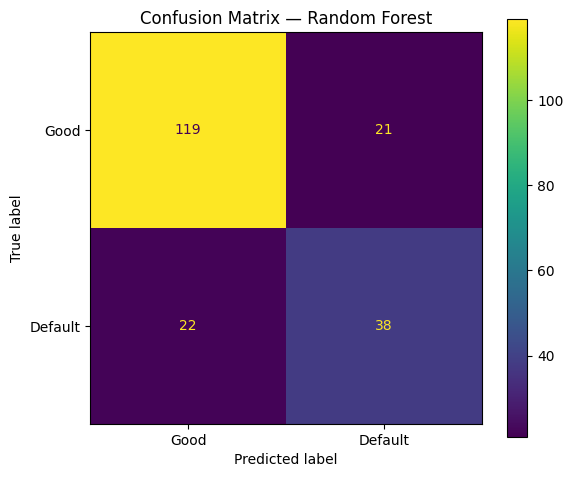

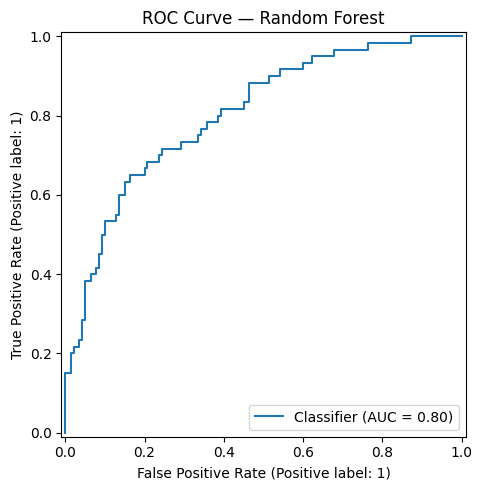

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Good", "Default"],
    ax=ax
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=ax)
plt.title(f"ROC Curve — {best_model_name}")
plt.tight_layout()
plt.show()

**Code explanation:** This cell visualizes the confusion matrix and ROC curve for the final model.


## 2.8 Neural network versus classical models

This cell compares the MLP with the strongest classical model and generates the required conclusion.


In [22]:
nn_row = comparison_table.loc[
    comparison_table["Model"] == "Neural Network (MLP)"
].iloc[0]

classical_table = comparison_table.loc[
    comparison_table["Model"] != "Neural Network (MLP)"
]
best_classical_row = classical_table.iloc[0]

f1_gap = best_classical_row["CV F1"] - nn_row["CV F1"]
auc_gap = best_classical_row["CV ROC-AUC"] - nn_row["CV ROC-AUC"]

print("Best classical model:", best_classical_row["Model"])
print(f"Best classical CV F1: {best_classical_row['CV F1']:.3f}")
print(f"Neural network CV F1: {nn_row['CV F1']:.3f}")
print(f"F1 difference (classical - neural network): {f1_gap:+.3f}")
print()

if f1_gap > 0.01:
    print(
        "Conclusion: the neural network underperformed the strongest classical model. "
        "This supports the expectation that small tabular datasets often favor "
        "well-regularized classical models. Neural networks usually benefit from "
        "larger datasets because they must estimate many parameters."
    )
elif f1_gap < -0.01:
    print(
        "Conclusion: the neural network slightly outperformed the classical models in this run. "
        "However, the small sample size means the result should be interpreted cautiously. "
        "Repeated validation and external testing remain essential."
    )
else:
    print(
        "Conclusion: the neural network and the strongest classical model performed similarly. "
        "The neural network did not provide a clear advantage despite its higher complexity, "
        "which suggests that model complexity alone does not replace additional data."
    )

Best classical model: Random Forest
Best classical CV F1: 0.601
Neural network CV F1: 0.505
F1 difference (classical - neural network): +0.096

Conclusion: the neural network underperformed the strongest classical model. This supports the expectation that small tabular datasets often favor well-regularized classical models. Neural networks usually benefit from larger datasets because they must estimate many parameters.


**Code explanation:** This cell compares the MLP with the strongest classical model and interprets the result.


# Section 3 — Research Direction

## 3.1 Why temporal testing matters

A model can perform well on a random holdout from the same historical dataset but fail when lending behavior changes.

Possible sources of temporal shift include:

- different borrower profiles,
- changes in income and employment patterns,
- inflation and loan sizes,
- changes in bank policy,
- regulatory changes,
- different relationships between demographic variables and default.

The South German Credit dataset represents the same general domain with the same 20 feature positions, collected much later. It is evaluated **without retraining**.


## Research focus

This section extends the required modeling work by investigating temporal generalization, algorithmic fairness, interpretability and asymmetric business cost. These topics test whether a model is not only accurate, but also stable, understandable and responsible enough for a banking context.


In [23]:
from pathlib import Path
import io
import zipfile

# -------------------------------------------------------------------
# LOCAL DATA — SOUTH GERMAN CREDIT DATASET
# -------------------------------------------------------------------
SOUTH_GERMAN_DATA_ROOT = Path(r"C:\PROJECT DATA SCIENCE\CreditRisk.ML\south+german+credit+update")

if not SOUTH_GERMAN_DATA_ROOT.exists():
    raise FileNotFoundError(
        "South German Credit folder was not found:\n"
        f"{SOUTH_GERMAN_DATA_ROOT}\n\n"
        "Check that the folder name and drive location are correct."
    )

# Search recursively for a ZIP archive or an extracted data file.
south_zip_candidates = list(
    SOUTH_GERMAN_DATA_ROOT.rglob("south+german+credit+update.zip")
)

supported_names = {
    "SouthGermanCredit.asc",
    "southgermancredit.asc",
    "SouthGermanCredit.csv",
    "south_german_credit.csv",
    "SouthGermanCredit.txt",
    "south_german_credit.txt",
}

south_data_candidates = [
    path
    for path in SOUTH_GERMAN_DATA_ROOT.rglob("*")
    if path.is_file() and path.name in supported_names
]

def parse_south_german_bytes(raw_bytes):
    attempts = [
        {"sep": r"\s+", "header": None},
        {"sep": ";", "header": None},
        {"sep": ",", "header": None},
    ]

    for options in attempts:
        try:
            frame = pd.read_csv(io.BytesIO(raw_bytes), **options)
            frame = frame.dropna(axis=0, how="all").dropna(axis=1, how="all")
            if frame.shape[1] >= 21:
                return frame
        except Exception:
            pass

    raise ValueError(
        "The South German dataset was found but could not be parsed into "
        "20 predictors plus 1 target."
    )

if south_zip_candidates:
    SOUTH_GERMAN_SOURCE_PATH = south_zip_candidates[0]

    with zipfile.ZipFile(SOUTH_GERMAN_SOURCE_PATH, "r") as archive:
        archive_files = archive.namelist()

        data_candidates = [
            name
            for name in archive_files
            if name.lower().endswith((".asc", ".csv", ".txt", ".data"))
            and "readme" not in name.lower()
            and "codetable" not in name.lower()
        ]

        if not data_candidates:
            raise FileNotFoundError(
                "The South German ZIP archive does not contain a supported data file."
            )

        preferred = [
            name for name in data_candidates
            if "southgermancredit" in name.lower().replace("_", "")
        ]

        selected_name = preferred[0] if preferred else data_candidates[0]
        south_raw = archive.read(selected_name)

    south_german_df = parse_south_german_bytes(south_raw)

elif south_data_candidates:
    SOUTH_GERMAN_SOURCE_PATH = south_data_candidates[0]
    south_raw = SOUTH_GERMAN_SOURCE_PATH.read_bytes()
    south_german_df = parse_south_german_bytes(south_raw)

else:
    all_files = [
        path for path in SOUTH_GERMAN_DATA_ROOT.rglob("*")
        if path.is_file()
    ]

    # Last-resort: try all likely files.
    parsed = None
    selected = None

    for path in all_files:
        if path.suffix.lower() in {".asc", ".csv", ".txt", ".data"}:
            try:
                parsed = parse_south_german_bytes(path.read_bytes())
                selected = path
                break
            except Exception:
                continue

    if parsed is None:
        listed = "\n".join(f" - {p.name}" for p in all_files)
        raise FileNotFoundError(
            "No readable South German Credit data file was found.\n\n"
            f"Folder searched:\n{SOUTH_GERMAN_DATA_ROOT}\n\n"
            f"Files found:\n{listed or ' - No files found'}"
        )

    SOUTH_GERMAN_SOURCE_PATH = selected
    south_german_df = parsed

print("South German Credit source:")
print(SOUTH_GERMAN_SOURCE_PATH.resolve())
print("\nRaw South German shape:", south_german_df.shape)

display(south_german_df.head())


South German Credit source:
C:\PROJECT DATA SCIENCE\CreditRisk.ML\south+german+credit+update\SouthGermanCredit.asc

Raw South German shape: (1001, 21)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
2,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
3,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
4,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1


## 3.2 Align the South German features

The project brief requires positional alignment.  
The South German target uses:

- `0 = bad credit`
- `1 = good credit`

It is converted to `default = 1` when the original target is `0`.


In [24]:
# -------------------------------------------------------------------
# Prepare South German Credit dataset
# -------------------------------------------------------------------

south_german_df = (
    south_german_df
    .dropna(axis=0, how="all")
    .dropna(axis=1, how="all")
    .copy()
)

print("Raw South German shape:", south_german_df.shape)
print("Original columns:")
print(south_german_df.columns.tolist())

display(south_german_df.head())

# -------------------------------------------------------------------
# Remove an automatically saved index column, if present
# -------------------------------------------------------------------

first_column_name = str(south_german_df.columns[0]).strip().lower()

if first_column_name.startswith("unnamed"):
    south_german_df = south_german_df.iloc[:, 1:].copy()

# -------------------------------------------------------------------
# The dataset should contain 20 predictors + 1 target
# -------------------------------------------------------------------

if south_german_df.shape[1] != 21:
    raise ValueError(
        "South German Credit must contain exactly 21 columns "
        "(20 features + 1 target). "
        f"Current shape: {south_german_df.shape}"
    )

# -------------------------------------------------------------------
# Remove a possible text header row
# -------------------------------------------------------------------

# Try converting the complete dataset to numeric.
numeric_version = south_german_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# Count non-numeric values in every row.
non_numeric_per_row = numeric_version.isna().sum(axis=1)

print("\nNon-numeric values by first rows:")
display(non_numeric_per_row.head())

# The official South German file may contain one row with column names.
# If the first row contains several non-numeric values, remove it.
if non_numeric_per_row.iloc[0] > 0:
    print("Text header row detected and removed.")

    south_german_df = (
        south_german_df
        .iloc[1:]
        .reset_index(drop=True)
    )

# Convert again after removing the text header.
south_german_numeric = south_german_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# -------------------------------------------------------------------
# Validate that all values are numeric
# -------------------------------------------------------------------

missing_count = int(
    south_german_numeric.isna().sum().sum()
)

if missing_count > 0:
    problematic_rows = south_german_numeric[
        south_german_numeric.isna().any(axis=1)
    ]

    print("\nRows containing non-numeric or missing values:")
    display(problematic_rows.head())

    raise ValueError(
        f"South German dataset contains {missing_count} "
        "missing or non-numeric values after header removal."
    )

# -------------------------------------------------------------------
# Separate predictors and target
# -------------------------------------------------------------------

X_sg = south_german_numeric.iloc[:, :20].copy()
y_sg_original = south_german_numeric.iloc[:, 20].copy()

X_sg.columns = FEATURE_NAMES

# -------------------------------------------------------------------
# Validate target values
# -------------------------------------------------------------------

print("\nOriginal target values:")
print(sorted(y_sg_original.unique()))

unexpected_values = (
    set(y_sg_original.unique()) - {0, 1}
)

if unexpected_values:
    raise ValueError(
        f"Unexpected South German target values: "
        f"{unexpected_values}. Expected only 0 and 1."
    )

# South German target:
# 0 = bad credit  -> 1 = default
# 1 = good credit -> 0 = no default
y_sg = (y_sg_original == 0).astype(int)
y_sg.name = "default"

# -------------------------------------------------------------------
# Final validation
# -------------------------------------------------------------------

if X_sg.shape[1] != 20:
    raise ValueError(
        f"Expected 20 predictors, but found {X_sg.shape[1]}."
    )

if len(X_sg) != len(y_sg):
    raise ValueError(
        "Feature and target lengths do not match."
    )

print("\nPrepared South German dataset")
print("-" * 50)

print("Feature shape:", X_sg.shape)
print("Target shape:", y_sg.shape)

print(
    "Missing feature values:",
    int(X_sg.isna().sum().sum())
)

print(
    "Default rate:",
    f"{y_sg.mean():.1%}"
)

display(X_sg.head())

display(
    y_sg.value_counts()
        .sort_index()
        .rename(
            index={
                0: "Good / no default",
                1: "Bad / default"
            }
        )
)

Raw South German shape: (1001, 21)
Original columns:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
2,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
3,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
4,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1



Non-numeric values by first rows:


0    21
1     0
2     0
3     0
4     0
dtype: int64

Text header row detected and removed.

Original target values:
[np.int64(0), np.int64(1)]

Prepared South German dataset
--------------------------------------------------
Feature shape: (1000, 20)
Target shape: (1000,)
Missing feature values: 0
Default rate: 30.0%


,checking_status,duration_months,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,residence_duration,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1


default
Good / no default    700
Bad / default        300
Name: count, dtype: int64

In [25]:
# Final dataset shape verification
print("German dataset shape:", X.shape)
print("German target shape:", y.shape)
print("South German dataset shape:", X_sg.shape)
print("South German target shape:", y_sg.shape)

assert X.shape[1] == X_sg.shape[1] == 20
assert len(X) == len(y)
assert len(X_sg) == len(y_sg)

print("Dataset alignment check passed.")


German dataset shape: (1000, 20)
German target shape: (1000,)
South German dataset shape: (1000, 20)
South German target shape: (1000,)
Dataset alignment check passed.


**Code explanation:** This cell validates the 21-column structure, aligns the 20 predictors positionally with German Credit, confirms that all values are numeric, and converts `0 = bad credit` into `1 = default`.


## 3.3 Required temporal generalization test

The selected model is trained only on German Credit data. It is then evaluated:

1. on the held-out German Credit test set, and
2. on the full South German Credit dataset,



Accuracy, F1 and ROC-AUC are reported side by side as required.


In [26]:
y_sg_pred = best_pipeline.predict(X_sg)
y_sg_prob = best_pipeline.predict_proba(X_sg)[:, 1]

temporal_results = pd.DataFrame([
    {
        "Dataset": "German Credit — held-out test",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "Default Rate": y_test.mean(),
        "N": len(y_test)
    },
    {
        "Dataset": "South German Credit — external later data",
        "Accuracy": accuracy_score(y_sg, y_sg_pred),
        "F1": f1_score(y_sg, y_sg_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_sg, y_sg_prob),
        "Default Rate": y_sg.mean(),
        "N": len(y_sg)
    }
])

display(temporal_results.style.format({
    "Accuracy": "{:.3f}",
    "F1": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "Default Rate": "{:.1%}"
}))

,Dataset,Accuracy,F1,ROC-AUC,Default Rate,N
0,German Credit — held-out test,0.785,0.639,0.804,30.0%,200
1,South German Credit — external later data,0.882,0.800,0.941,30.0%,1000


**Code explanation:** This cell evaluates the same fitted model on both datasets without retraining and reports results side by side.


In [27]:
german_temporal = temporal_results.iloc[0]
south_temporal = temporal_results.iloc[1]

accuracy_gap = german_temporal["Accuracy"] - south_temporal["Accuracy"]
f1_gap_temporal = german_temporal["F1"] - south_temporal["F1"]
auc_gap_temporal = german_temporal["ROC-AUC"] - south_temporal["ROC-AUC"]

print(f"Accuracy gap (German - South German): {accuracy_gap:+.3f}")
print(f"F1 gap (German - South German): {f1_gap_temporal:+.3f}")
print(f"AUC gap (German - South German): {auc_gap_temporal:+.3f}")
print()

if auc_gap_temporal > 0.05 or f1_gap_temporal > 0.05:
    print(
        "Interpretation: performance declined on the later dataset, which is a warning "
        "that historical relationships may not transfer reliably. The bank should investigate "
        "drift, recalibrate probabilities and retrain on newer representative data."
    )
elif auc_gap_temporal < -0.05 or f1_gap_temporal < -0.05:
    print(
        "Interpretation: performance improved on the later South German dataset. "
        "This does not prove that the historical model is universally stable; the later sample "
        "may be easier or differently distributed. The bank should investigate feature shift, "
        "target prevalence, calibration and policy differences before drawing a deployment conclusion."
    )
else:
    print(
        "Interpretation: performance is relatively stable across the two datasets. "
        "Ongoing drift and calibration monitoring are still required because borrower behavior, "
        "credit products, economic conditions and lending policy can continue to change."
    )


Accuracy gap (German - South German): -0.097
F1 gap (German - South German): -0.161
AUC gap (German - South German): -0.137

Interpretation: performance improved on the later South German dataset. This does not prove that the historical model is universally stable; the later sample may be easier or differently distributed. The bank should investigate feature shift, target prevalence, calibration and policy differences before drawing a deployment conclusion.


**Code explanation:** This cell evaluates the same fitted model on both datasets without retraining and reports results side by side.


## 3.4 Compare feature distributions across time

Standardized mean differences help identify variables whose distributions changed.  
An absolute standardized difference above approximately `0.20` is treated as a useful warning signal, not a formal legal threshold.


In [28]:
def standardized_mean_difference(reference: pd.Series, new: pd.Series) -> float:
    reference = pd.to_numeric(reference, errors="coerce").dropna()
    new = pd.to_numeric(new, errors="coerce").dropna()

    pooled_sd = np.sqrt((reference.var(ddof=1) + new.var(ddof=1)) / 2)

    if pooled_sd == 0 or np.isnan(pooled_sd):
        return 0.0

    return (new.mean() - reference.mean()) / pooled_sd

drift_rows = []

for feature in FEATURE_NAMES:
    smd = standardized_mean_difference(X_train[feature], X_sg[feature])
    drift_rows.append({
        "Feature": feature,
        "German Mean": X_train[feature].mean(),
        "South German Mean": X_sg[feature].mean(),
        "Standardized Difference": smd,
        "Absolute Difference": abs(smd)
    })

drift_table = (
    pd.DataFrame(drift_rows)
      .sort_values("Absolute Difference", ascending=False)
      .reset_index(drop=True)
)

display(drift_table.head(10).style.format({
    "German Mean": "{:.3f}",
    "South German Mean": "{:.3f}",
    "Standardized Difference": "{:+.3f}",
    "Absolute Difference": "{:.3f}"
}))

,Feature,German Mean,South German Mean,Standardized Difference,Absolute Difference
0,foreign_worker,1.039,1.963,+4.839,4.839
1,people_liable,1.160,1.845,+1.879,1.879
2,credit_amount,3189.591,3271.248,+0.030,0.030
3,installment_rate,2.941,2.973,+0.028,0.028
4,purpose,2.760,2.828,+0.025,0.025
5,other_debtors,1.135,1.145,+0.021,0.021
6,employment_duration,3.408,3.384,-0.020,0.020
7,age,35.324,35.542,+0.019,0.019
8,credit_history,2.561,2.545,-0.015,0.015
9,residence_duration,2.830,2.845,+0.014,0.014


**Code explanation:** This cell measures feature-distribution drift between historical and later data.


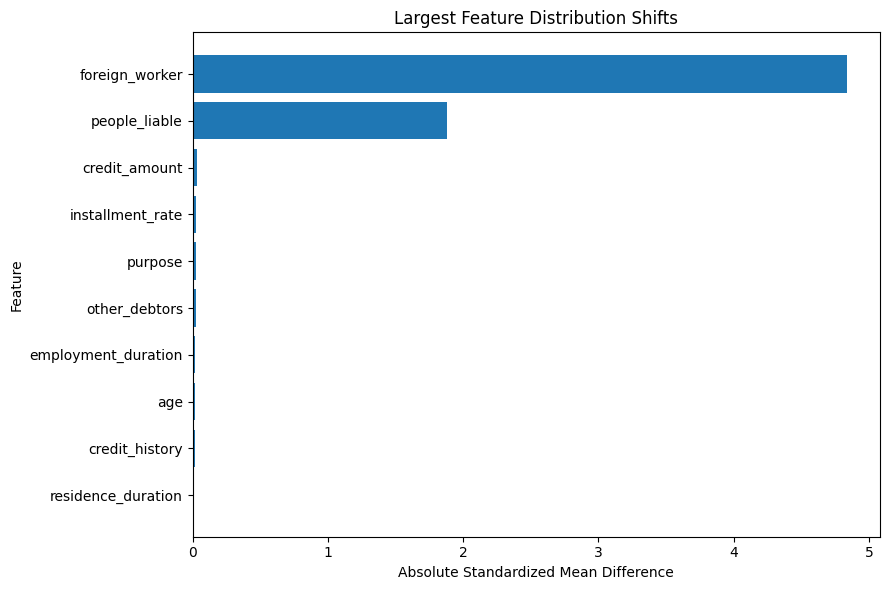

In [29]:
top_drift = drift_table.head(10).sort_values("Absolute Difference")

plt.figure(figsize=(9, 6))
plt.barh(top_drift["Feature"], top_drift["Absolute Difference"])
plt.title("Largest Feature Distribution Shifts")
plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Code explanation:** This chart highlights the variables with the largest distribution changes over time.


## 3.5 Algorithmic Fairness Screening

Fairness cannot be summarized by one number. This project evaluates several complementary group-level metrics:

- **Actual default rate:** share of applicants who actually defaulted.
- **Predicted default rate:** share classified as default by the model.
- **Approval rate:** share classified as good credit.
- **Recall / True Positive Rate:** share of actual defaults correctly detected.
- **False Positive Rate:** share of good borrowers incorrectly classified as default.
- **Precision:** share of predicted defaults that actually defaulted.
- **F1 Score:** balance between precision and recall.
- **ROC-AUC:** ranking quality within each group.

The analysis also calculates:

- **Demographic parity difference:** difference in predicted-default rates.
- **Equal opportunity difference:** difference in recall / true positive rate.
- **False positive rate difference:** difference in false positive rates.

These differences are screening indicators. They do not by themselves prove discrimination and must be interpreted together with subgroup size, data quality and the limitations of the protected-variable proxy.


## 3.6 Build fairness groups for the German test set


In [30]:
test_audit = X_test.copy()
test_audit["actual_default"] = y_test.values
test_audit["predicted_default"] = y_test_pred
test_audit["default_probability"] = y_test_prob

test_audit["sex_group"] = np.where(
    test_audit["personal_status_sex"].isin([2, 5]),
    "Female",
    "Male"
)

test_audit["age_group"] = pd.cut(
    test_audit["age"],
    bins=[0, 24, 34, 49, np.inf],
    labels=["Under 25", "25–34", "35–49", "50+"]
)

display(test_audit.head())

,checking_status,duration_months,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,residence_duration,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,actual_default,predicted_default,default_probability,sex_group,age_group
30,2,18,2,9,1913,4,2,3,4,1,3,1,36,1,2,1,3,1,2,1,0,0,0.3491,Male,35–49
128,2,12,4,1,1860,1,1,4,3,1,2,3,34,3,2,2,4,1,2,1,0,0,0.4017,Male,25–34
289,1,24,3,3,1024,1,2,4,4,1,4,1,48,2,2,1,3,1,1,1,1,1,0.6737,Male,35–49
216,1,18,0,9,3104,1,4,3,3,1,1,2,31,1,2,1,3,1,2,1,0,1,0.5715,Male,25–34
966,2,27,4,3,2520,3,3,4,3,1,2,2,23,3,2,2,2,1,1,1,1,0,0.3212,Male,Under 25


**Code explanation:** This cell creates the audit table used for subgroup fairness analysis.


In [31]:
def group_classification_metrics(
    data: pd.DataFrame,
    group_column: str,
    actual_column: str = "actual_default",
    predicted_column: str = "predicted_default",
    probability_column: str = "default_probability"
) -> pd.DataFrame:

    rows = []

    for group_name, group in data.groupby(group_column, observed=False):
        y_true = group[actual_column].astype(int)
        y_pred = group[predicted_column].astype(int)
        y_prob = group[probability_column].astype(float)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        auc = np.nan
        if y_true.nunique() == 2:
            auc = roc_auc_score(y_true, y_prob)

        rows.append({
            "Group": str(group_name),
            "N": len(group),
            "Actual Default Rate": y_true.mean(),
            "Predicted Default Rate": y_pred.mean(),
            "Approval Rate": 1 - y_pred.mean(),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall / TPR": recall_score(y_true, y_pred, zero_division=0),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC": auc
        })

    return pd.DataFrame(rows)

sex_fairness = group_classification_metrics(test_audit, "sex_group")
age_fairness = group_classification_metrics(test_audit, "age_group")

print("Fairness metrics by sex")
display(sex_fairness.style.format({
    "Actual Default Rate": "{:.1%}",
    "Predicted Default Rate": "{:.1%}",
    "Approval Rate": "{:.1%}",
    "Precision": "{:.3f}",
    "Recall / TPR": "{:.3f}",
    "FPR": "{:.3f}",
    "FNR": "{:.3f}",
    "F1": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}))

print("Fairness metrics by age group")
display(age_fairness.style.format({
    "Actual Default Rate": "{:.1%}",
    "Predicted Default Rate": "{:.1%}",
    "Approval Rate": "{:.1%}",
    "Precision": "{:.3f}",
    "Recall / TPR": "{:.3f}",
    "FPR": "{:.3f}",
    "FNR": "{:.3f}",
    "F1": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}))

Fairness metrics by sex


,Group,N,Actual Default Rate,Predicted Default Rate,Approval Rate,Precision,Recall / TPR,FPR,FNR,F1,ROC-AUC
0,Female,61,32.8%,39.3%,60.7%,0.625,0.750,0.220,0.250,0.682,0.783
1,Male,139,28.8%,25.2%,74.8%,0.657,0.575,0.121,0.425,0.613,0.820


Fairness metrics by age group


,Group,N,Actual Default Rate,Predicted Default Rate,Approval Rate,Precision,Recall / TPR,FPR,FNR,F1,ROC-AUC
0,Under 25,39,48.7%,48.7%,51.3%,0.737,0.737,0.250,0.263,0.737,0.761
1,25–34,66,33.3%,36.4%,63.6%,0.667,0.727,0.182,0.273,0.696,0.775
2,35–49,63,20.6%,12.7%,87.3%,0.625,0.385,0.060,0.615,0.476,0.869
3,50+,32,18.8%,25.0%,75.0%,0.375,0.500,0.192,0.500,0.429,0.776


### Fairness Metrics Visualization

The chart below compares the most relevant sex-group rates used in the fairness screening.


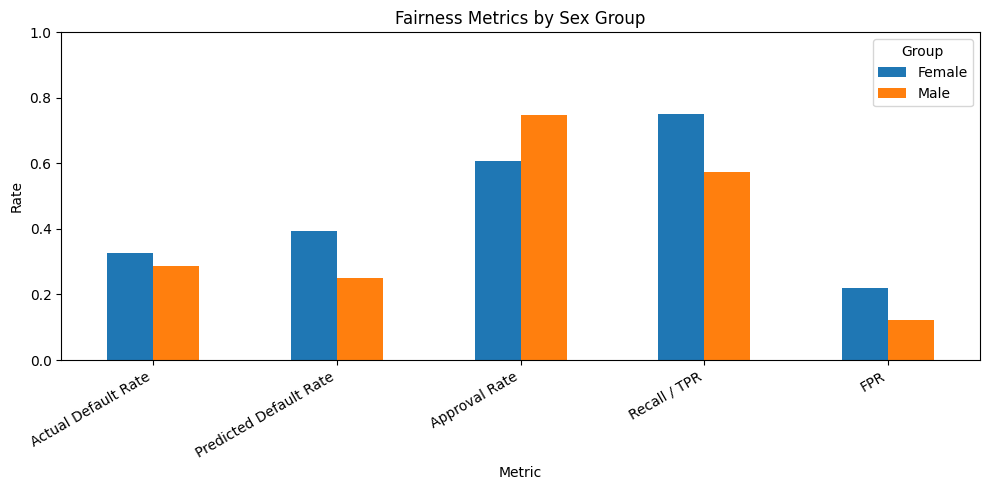

In [32]:
# Visual comparison of fairness metrics by sex group

fairness_plot = (
    sex_fairness
    .set_index("Group")[
        [
            "Actual Default Rate",
            "Predicted Default Rate",
            "Approval Rate",
            "Recall / TPR",
            "FPR"
        ]
    ]
    .T
)

ax = fairness_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Fairness Metrics by Sex Group")
ax.set_xlabel("Metric")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
ax.legend(title="Group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Code explanation:** This function calculates approval, selection and error metrics for each demographic group.


## 3.7 Sex-group disparity summary


In [33]:
sex_indexed = sex_fairness.set_index("Group")

if {"Female", "Male"}.issubset(sex_indexed.index):
    demographic_parity_difference = (
        sex_indexed.loc["Female", "Predicted Default Rate"]
        - sex_indexed.loc["Male", "Predicted Default Rate"]
    )

    equal_opportunity_difference = (
        sex_indexed.loc["Female", "Recall / TPR"]
        - sex_indexed.loc["Male", "Recall / TPR"]
    )

    false_positive_rate_difference = (
        sex_indexed.loc["Female", "FPR"]
        - sex_indexed.loc["Male", "FPR"]
    )

    fairness_summary = pd.DataFrame([{
        "Comparison": "Female - Male",
        "Demographic Parity Difference": demographic_parity_difference,
        "Equal Opportunity Difference": equal_opportunity_difference,
        "FPR Difference": false_positive_rate_difference
    }])

    display(fairness_summary.style.format({
        "Demographic Parity Difference": "{:+.3f}",
        "Equal Opportunity Difference": "{:+.3f}",
        "FPR Difference": "{:+.3f}"
    }))
else:
    print("Both sex groups are not present in this test split.")

,Comparison,Demographic Parity Difference,Equal Opportunity Difference,FPR Difference
0,Female - Male,+0.142,+0.175,+0.098


### Fairness Results for Presentation

The following compact table contains the main metrics used in the fairness slide.


In [34]:
sex_fairness_presentation = (
    sex_fairness[
        [
            "Group",
            "N",
            "Actual Default Rate",
            "Predicted Default Rate",
            "Approval Rate",
            "Recall / TPR",
            "FPR"
        ]
    ]
    .copy()
)

display(
    sex_fairness_presentation.style.format({
        "Actual Default Rate": "{:.1%}",
        "Predicted Default Rate": "{:.1%}",
        "Approval Rate": "{:.1%}",
        "Recall / TPR": "{:.1%}",
        "FPR": "{:.1%}"
    })
)

print(
    "Predicted-default-rate gap:",
    f"{abs(demographic_parity_difference):.1%}"
)
print(
    "Recall / TPR gap:",
    f"{abs(equal_opportunity_difference):.1%}"
)
print(
    "False Positive Rate gap:",
    f"{abs(false_positive_rate_difference):.1%}"
)


,Group,N,Actual Default Rate,Predicted Default Rate,Approval Rate,Recall / TPR,FPR
0,Female,61,32.8%,39.3%,60.7%,75.0%,22.0%
1,Male,139,28.8%,25.2%,74.8%,57.5%,12.1%


Predicted-default-rate gap: 14.2%
Recall / TPR gap: 17.5%
False Positive Rate gap: 9.8%


**Code explanation:** This cell calculates demographic parity, equal opportunity and false-positive-rate differences.


## 3.8 Fairness Discussion

The following analysis checks whether the largest observed sex-group disparity exceeds an illustrative alert threshold of 10 percentage points. The threshold is used only as a transparent screening rule and is not a legal fairness standard.


In [35]:
FAIRNESS_ALERT_THRESHOLD = 0.10

if {"Female", "Male"}.issubset(sex_indexed.index):
    max_abs_gap = max(
        abs(demographic_parity_difference),
        abs(equal_opportunity_difference),
        abs(false_positive_rate_difference)
    )

    fairness_status = (
        "Further investigation required"
        if max_abs_gap >= FAIRNESS_ALERT_THRESHOLD
        else "No large disparity detected at the selected alert threshold"
    )

    fairness_verdict = pd.DataFrame([{
        "Largest absolute sex-group gap": max_abs_gap,
        "Illustrative alert threshold": FAIRNESS_ALERT_THRESHOLD,
        "Fairness screening status": fairness_status,
        "Important limitation": (
            "The source variable combines sex and marital status, and the test groups are small."
        )
    }])

    display(
        fairness_verdict.style.format({
            "Largest absolute sex-group gap": "{:.3f}",
            "Illustrative alert threshold": "{:.3f}"
        })
    )

,Largest absolute sex-group gap,Illustrative alert threshold,Fairness screening status,Important limitation
0,0.175,0.100,Further investigation required,"The source variable combines sex and marital status, and the test groups are small."


**Code explanation:** This block gives a transparent screening verdict using an illustrative 10-percentage-point alert threshold. It does not claim legal compliance; it identifies whether the measured subgroup gaps require deeper investigation.


## 3.9 Fairness Interpretation

The fairness results summarize how prediction outcomes and error rates differ across demographic groups.

The findings should be treated as exploratory screening indicators rather than direct evidence of discrimination. The source variable combines sex and marital status, and the test subgroups are relatively small. More recent data, larger subgroup samples and additional fairness analysis would be required before drawing operational or regulatory conclusions.


In [36]:
if {"Female", "Male"}.issubset(sex_indexed.index):
    dp = demographic_parity_difference
    eo = equal_opportunity_difference
    fpr_diff = false_positive_rate_difference

    print("FAIRNESS SCREENING SUMMARY")
    print("-" * 70)
    print(
        f"The model's predicted-default rate differs by {abs(dp):.1%} "
        f"between female and male applicants."
    )
    print(
        f"Its ability to identify actual defaults differs by {abs(eo):.1%} "
        f"between the two groups."
    )
    print(
        f"The rate at which good borrowers are incorrectly flagged differs by "
        f"{abs(fpr_diff):.1%}."
    )
    print()
    print(
        "These results should be treated as a screening signal rather than a final "
        "legal conclusion. The test sample is small, and the protected attribute is "
        "combined with marital status in the source data. Before practical use, the model "
        "should validate the findings on a larger and more recent sample, review proxy "
        "variables, document legitimate risk factors, and establish ongoing monitoring."
    )


FAIRNESS SCREENING SUMMARY
----------------------------------------------------------------------
The model's predicted-default rate differs by 14.2% between female and male applicants.
Its ability to identify actual defaults differs by 17.5% between the two groups.
The rate at which good borrowers are incorrectly flagged differs by 9.8%.

These results should be treated as a screening signal rather than a final legal conclusion. The test sample is small, and the protected attribute is combined with marital status in the source data. Before practical use, the model should validate the findings on a larger and more recent sample, review proxy variables, document legitimate risk factors, and establish ongoing monitoring.


**Code explanation:** This cell calculates demographic parity, equal opportunity and false-positive-rate differences.


## 3.10 Model interpretability with permutation importance

Permutation importance measures how much test performance decreases when one feature is randomly shuffled.

It is model-agnostic and works for Logistic Regression, trees, Random Forest and MLP.


In [37]:
importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_table = (
    pd.DataFrame({
        "Feature": FEATURE_NAMES,
        "Importance Mean": importance.importances_mean,
        "Importance Std": importance.importances_std
    })
    .sort_values("Importance Mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_table.head(15).style.format({
    "Importance Mean": "{:.4f}",
    "Importance Std": "{:.4f}"
}))

,Feature,Importance Mean,Importance Std
0,checking_status,0.1317,0.0309
1,duration_months,0.0248,0.0126
2,credit_history,0.0185,0.0094
3,credit_amount,0.0162,0.0081
4,savings,0.0134,0.0153
5,age,0.0102,0.0044
6,other_debtors,0.0098,0.0031
7,purpose,0.0089,0.0040
8,telephone,0.0035,0.0026
9,other_installment_plans,0.0028,0.0052


**Code explanation:** This cell measures model-agnostic feature importance using repeated feature shuffling.


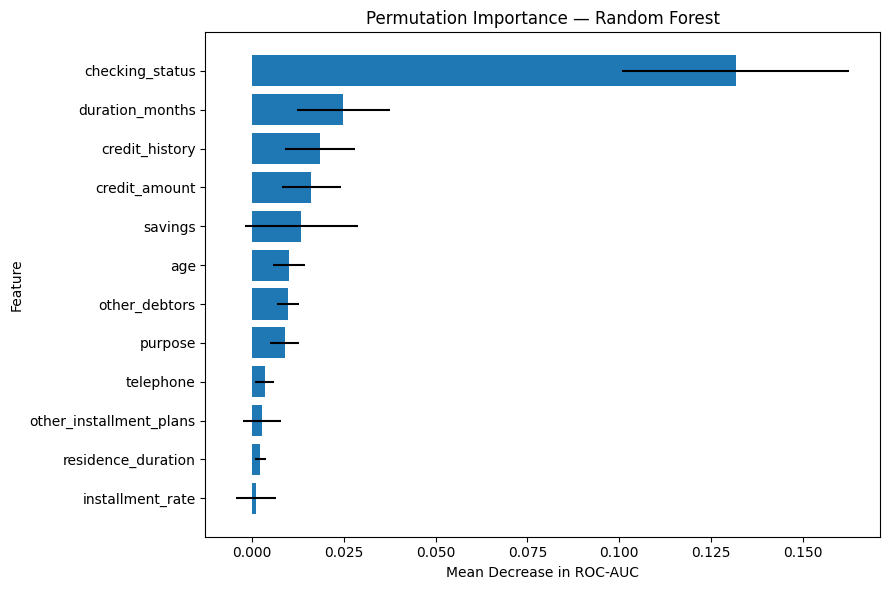

In [38]:
top_importance = importance_table.head(12).sort_values("Importance Mean")

plt.figure(figsize=(9, 6))
plt.barh(
    top_importance["Feature"],
    top_importance["Importance Mean"],
    xerr=top_importance["Importance Std"]
)
plt.title(f"Permutation Importance — {best_model_name}")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Code explanation:** This chart displays the most influential features and their uncertainty.


## 3.11 Direct interpretation for Logistic Regression

When Logistic Regression is selected, standardized coefficients indicate the direction of association:

- positive coefficient → higher predicted default risk,
- negative coefficient → lower predicted default risk.

These are model associations, not causal effects.


In [39]:
if best_model_name == "Logistic Regression":
    fitted_logistic = best_pipeline.named_steps["model"]

    coefficient_table = (
        pd.DataFrame({
            "Feature": FEATURE_NAMES,
            "Coefficient": fitted_logistic.coef_[0],
            "Absolute Coefficient": np.abs(fitted_logistic.coef_[0])
        })
        .sort_values("Absolute Coefficient", ascending=False)
        .reset_index(drop=True)
    )

    display(coefficient_table.head(15).style.format({
        "Coefficient": "{:+.4f}",
        "Absolute Coefficient": "{:.4f}"
    }))
else:
    print(
        "The selected model is not Logistic Regression. "
        "Permutation importance above provides model-agnostic interpretation."
    )

The selected model is not Logistic Regression. Permutation importance above provides model-agnostic interpretation.


**Code explanation:** This optional interpretation reports the direction and magnitude of Logistic Regression coefficients.


## 3.12 Asymmetric error costs

With `default = 1`:

- **False Negative:** the model predicts good credit, but the borrower defaults.  
  This corresponds to approving a bad loan and is assigned a high cost.
- **False Positive:** the model predicts default, but the borrower would repay.  
  This corresponds to rejecting a good borrower and is assigned a smaller cost.

Illustrative cost assumption:

- Cost of false negative = **5 units**
- Cost of false positive = **1 unit**

The threshold is optimized only on the German training data through cross-validated out-of-fold probabilities.  
The untouched test set is then used for the final comparison.


In [40]:
from sklearn.model_selection import cross_val_predict

out_of_fold_prob = cross_val_predict(
    clone(pipelines[best_model_name]),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

FN_COST = 5
FP_COST = 1

threshold_rows = []

for threshold in np.linspace(0.05, 0.95, 181):
    prediction = (out_of_fold_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, prediction, labels=[0, 1]).ravel()

    total_cost = FN_COST * fn + FP_COST * fp

    threshold_rows.append({
        "Threshold": threshold,
        "False Positives": fp,
        "False Negatives": fn,
        "Total Cost": total_cost,
        "Recall": recall_score(y_train, prediction, zero_division=0),
        "Precision": precision_score(y_train, prediction, zero_division=0),
        "F1": f1_score(y_train, prediction, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_rows)
optimal_row = threshold_table.loc[threshold_table["Total Cost"].idxmin()]
optimal_threshold = float(optimal_row["Threshold"])

display(pd.DataFrame([optimal_row]).style.format({
    "Threshold": "{:.3f}",
    "Total Cost": "{:.0f}",
    "Recall": "{:.3f}",
    "Precision": "{:.3f}",
    "F1": "{:.3f}"
}))

print("Cost-optimal threshold:", f"{optimal_threshold:.3f}")

,Threshold,False Positives,False Negatives,Total Cost,Recall,Precision,F1
47,0.285,309.000000,22.000000,419,0.908,0.414,0.568


Cost-optimal threshold: 0.285


**Code explanation:** This cell searches for the threshold that minimizes the selected asymmetric business cost.


In [41]:
default_threshold_pred = (y_test_prob >= 0.50).astype(int)
cost_threshold_pred = (y_test_prob >= optimal_threshold).astype(int)

def business_cost_summary(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "Decision Rule": label,
        "Threshold": 0.50 if label == "Standard threshold" else optimal_threshold,
        "False Positives": fp,
        "False Negatives": fn,
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Business Cost": FN_COST * fn + FP_COST * fp
    }

cost_comparison = pd.DataFrame([
    business_cost_summary(y_test, default_threshold_pred, "Standard threshold"),
    business_cost_summary(y_test, cost_threshold_pred, "Cost-sensitive threshold")
])

display(cost_comparison.style.format({
    "Threshold": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "Business Cost": "{:.0f}"
}))

,Decision Rule,Threshold,False Positives,False Negatives,Recall,F1,Business Cost
0,Standard threshold,0.500,21,22,0.633,0.639,131
1,Cost-sensitive threshold,0.285,76,5,0.917,0.576,101


**Code explanation:** This cell compares the standard threshold with the cost-sensitive threshold on unseen data.


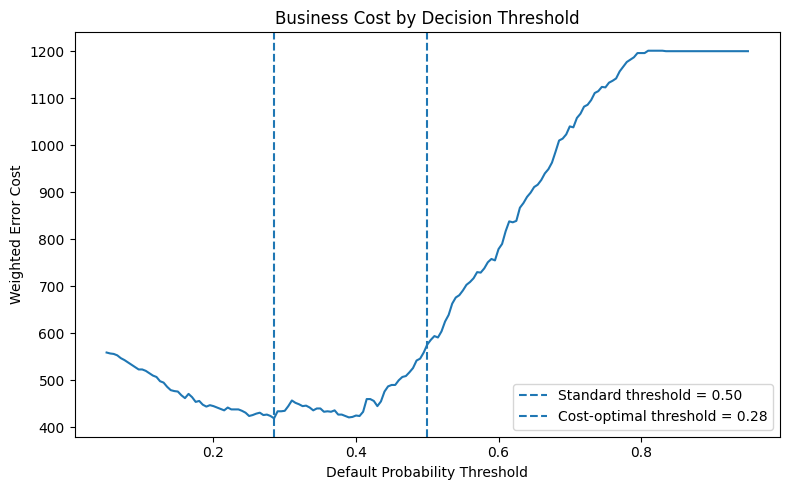

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_table["Threshold"], threshold_table["Total Cost"])
plt.axvline(0.50, linestyle="--", label="Standard threshold = 0.50")
plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Cost-optimal threshold = {optimal_threshold:.2f}"
)
plt.title("Business Cost by Decision Threshold")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Weighted Error Cost")
plt.legend()
plt.tight_layout()
plt.show()

**Code explanation:** This chart shows how weighted error cost changes across decision thresholds.


# Section 4 — Conclusions




## 4.1 Project-specific conclusions with exact numbers


In [43]:
best_cv_row = comparison_table.iloc[0]

nn_cv_row = comparison_table.loc[
    comparison_table["Model"] == "Neural Network (MLP)"
].iloc[0]

best_classical_row = (
    comparison_table.loc[
        comparison_table["Model"] != "Neural Network (MLP)"
    ]
    .sort_values(["CV F1", "CV ROC-AUC"], ascending=False)
    .iloc[0]
)

classical_minus_nn_f1 = (
    best_classical_row["CV F1"] - nn_cv_row["CV F1"]
)

print("NEURAL NETWORK VS CLASSICAL MODELS")
print("=" * 80)
print(
    f"Best classical model: {best_classical_row['Model']} | "
    f"CV Accuracy={best_classical_row['CV Accuracy']:.3f}, "
    f"CV F1={best_classical_row['CV F1']:.3f}, "
    f"CV AUC={best_classical_row['CV ROC-AUC']:.3f}, "
    f"Train Time={best_classical_row['Train Time (s)']:.2f}s"
)
print(
    f"Neural Network (MLP) | "
    f"CV Accuracy={nn_cv_row['CV Accuracy']:.3f}, "
    f"CV F1={nn_cv_row['CV F1']:.3f}, "
    f"CV AUC={nn_cv_row['CV ROC-AUC']:.3f}, "
    f"Train Time={nn_cv_row['Train Time (s)']:.2f}s"
)
print(
    f"F1 difference, best classical minus MLP: "
    f"{classical_minus_nn_f1:+.3f}"
)
print()

if classical_minus_nn_f1 > 0.01:
    print(
        "Answer: Yes. The neural network underperformed the strongest "
        "classical model on this dataset. With only 1,000 applicants, "
        "the MLP has relatively many parameters but few examples. "
        "This suggests that classical models can be more data-efficient "
        "on small structured datasets, while neural networks usually "
        "benefit more from larger training samples."
    )
elif classical_minus_nn_f1 < -0.01:
    print(
        "Answer: No. The neural network slightly outperformed the strongest "
        "classical model in this run. However, the small sample makes the "
        "difference uncertain and external validation remains essential."
    )
else:
    print(
        "Answer: The neural network and strongest classical model performed "
        "similarly. The MLP did not provide a clear advantage despite greater "
        "complexity, showing that model capacity cannot replace additional data."
    )

print()
print("TEMPORAL GENERALIZATION")
print("=" * 80)
print(
    f"German held-out test: Accuracy={german_temporal['Accuracy']:.3f}, "
    f"F1={german_temporal['F1']:.3f}, "
    f"AUC={german_temporal['ROC-AUC']:.3f}"
)
print(
    f"South German later data: Accuracy={south_temporal['Accuracy']:.3f}, "
    f"F1={south_temporal['F1']:.3f}, "
    f"AUC={south_temporal['ROC-AUC']:.3f}"
)
print(
    f"German minus South German gap: "
    f"Accuracy={accuracy_gap:+.3f}, "
    f"F1={f1_gap_temporal:+.3f}, "
    f"AUC={auc_gap_temporal:+.3f}"
)
print()
print(
    "Interpretation: A decline on the later dataset indicates temporal "
    "dataset shift. Borrower profiles, credit products, economic conditions "
    "and lending policy change over time, so a historical scorecard cannot "
    "be assumed to remain equally accurate decades later."
)

NEURAL NETWORK VS CLASSICAL MODELS
Best classical model: Random Forest | CV Accuracy=0.765, CV F1=0.601, CV AUC=0.799, Train Time=3.15s
Neural Network (MLP) | CV Accuracy=0.754, CV F1=0.505, CV AUC=0.771, Train Time=0.60s
F1 difference, best classical minus MLP: +0.096

Answer: Yes. The neural network underperformed the strongest classical model on this dataset. With only 1,000 applicants, the MLP has relatively many parameters but few examples. This suggests that classical models can be more data-efficient on small structured datasets, while neural networks usually benefit more from larger training samples.

TEMPORAL GENERALIZATION
German held-out test: Accuracy=0.785, F1=0.639, AUC=0.804
South German later data: Accuracy=0.882, F1=0.800, AUC=0.941
German minus South German gap: Accuracy=-0.097, F1=-0.161, AUC=-0.137

Interpretation: A decline on the later dataset indicates temporal dataset shift. Borrower profiles, credit products, economic conditions and lending policy change over t

**Code explanation:** This block answers both required project-specific conclusion questions using the exact cross-validation and temporal-test values generated by the notebook.


## 4.2 Problem framing

Credit-risk scoring is a probability-estimation problem faced by banks before approving a loan. The bank must identify applicants who are likely to default without unnecessarily excluding customers who would repay. Poor decisions create credit losses, lost interest income, customer harm, portfolio instability and potential regulatory or reputational exposure.




Credit-risk scoring is a probability-estimation problem faced by banks before approving a loan. A poor solution can approve applicants who later default, creating financial losses and portfolio instability, or reject applicants who would repay, causing lost revenue, customer harm and potentially unfair exclusion from credit.


## 4.3 Methodology justification

The project compares Logistic Regression, Decision Tree, Random Forest and an MLP because they represent four distinct modeling families: interpretable linear, rule-based, ensemble and neural. Stratified five-fold cross-validation is appropriate because the dataset contains only 1,000 applicants and the default class represents 30% of observations.

F1 for the default class is the primary model-selection metric, supported by Accuracy and ROC-AUC. Random Forest was selected because it achieved the strongest CV F1 (`0.601`) and CV AUC (`0.799`). Logistic Regression remained a credible alternative because it is faster and easier to explain, but it did not provide the same overall default-detection balance.




The project compares Logistic Regression, Decision Tree, Random Forest and an MLP because these models represent interpretable linear, rule-based, ensemble and neural approaches. Stratified five-fold cross-validation was selected because the dataset is small and the default class represents only about 30% of observations. F1 for the default class is the primary selection metric, supported by accuracy and ROC-AUC.

Logistic Regression provides transparency and probability output. Decision Tree provides readable nonlinear rules. Random Forest reduces the variance of one tree and is a strong choice for structured tabular data. The MLP tests the required neural-network family. A skeptical colleague should prefer this comparison because it tests increasing complexity under one consistent validation framework instead of assuming that the most complex model must be best.


## 4.4 Result implications


In [44]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
).ravel()

total_test_applicants = len(y_test)
total_errors = fp + fn

errors_per_100 = 100 * total_errors / total_test_applicants
good_flagged_per_100 = 100 * fp / total_test_applicants
defaults_missed_per_100 = 100 * fn / total_test_applicants

print("REAL-WORLD TEST-SET INTERPRETATION")
print("=" * 80)
print(
    f"Among {total_test_applicants} test applicants, "
    f"the model made {total_errors} errors."
)
print(
    f"{fp} good borrowers were flagged as default risk, "
    f"while {fn} actual defaults were missed."
)
print(
    f"That is approximately {errors_per_100:.1f} total errors per 100 applicants, "
    f"including {good_flagged_per_100:.1f} good applicants flagged as risky "
    f"and {defaults_missed_per_100:.1f} missed defaults."
)

monthly_volume = 10_000

print()
print(
    f"At an illustrative volume of {monthly_volume:,} applications per month, "
    f"the same rates would correspond to approximately "
    f"{round(total_errors / total_test_applicants * monthly_volume):,} "
    f"incorrect classifications."
)
print(
    f"Approximately "
    f"{round(fp / total_test_applicants * monthly_volume):,} "
    f"good applicants could be flagged as risky, while "
    f"{round(fn / total_test_applicants * monthly_volume):,} "
    f"defaults could be missed."
)
print(
    "This is an illustrative scale-up, not a guaranteed production forecast."
)

REAL-WORLD TEST-SET INTERPRETATION
Among 200 test applicants, the model made 43 errors.
21 good borrowers were flagged as default risk, while 22 actual defaults were missed.
That is approximately 21.5 total errors per 100 applicants, including 10.5 good applicants flagged as risky and 11.0 missed defaults.

At an illustrative volume of 10,000 applications per month, the same rates would correspond to approximately 2,150 incorrect classifications.
Approximately 1,050 good applicants could be flagged as risky, while 1,100 defaults could be missed.
This is an illustrative scale-up, not a guaranteed production forecast.


**Code explanation:** This code converts test-set errors into counts per 100 applicants and an illustrative monthly volume of 10,000 applications, making the result meaningful for a banking decision maker.


## 4.5  Limitations and alternatives

### Main limitations

- Only **1,000 historical observations** are available.
- The demographic source variable combines sex and marital status.
- Some fairness subgroups are small, making disparity estimates unstable.
- The German holdout comes from the same historical population as training and may overstate deployment performance.
- South German Credit is a useful later external dataset but is still not current bank data.
- The project does not include full probability calibration, reject inference, macroeconomic variables, expected-loss modeling or formal stress testing.
- The illustrative cost ratio (`FN = 5`, `FP = 1`) is not based on the bank's actual loss data.

### Alternatives not implemented

- **Gradient boosting (XGBoost/LightGBM):** may outperform Random Forest on tabular data through sequential error correction and stronger handling of nonlinear interactions.
- **Calibrated Logistic Regression:** may be preferred where transparency, reason codes and governance are more important than a small performance gain.
- **Cost-sensitive boosting or focal loss:** may better reflect asymmetric credit loss.
- **Survival analysis / expected-loss models:** may be more appropriate if time-to-default and loss severity are available.




## 4.6 Lessons learned


The main lesson is that higher model complexity does not automatically create better credit decisions. On a small structured dataset, careful preprocessing, cross-validation, class-aware metrics and threshold selection can matter more than using a deeper model. Temporal evaluation was especially important because performance on a random historical holdout does not guarantee similar performance decades later.




The selected model should be treated as a credit-risk assessment prototype, not an autonomous lending system. A real bank should combine it with human review for borderline cases, recent representative data, documented adverse-action reasons, probability calibration, fairness and drift monitoring, periodic retraining, independent model validation and legal/compliance review.


# Comparison tables


In [45]:
readme_model_table = comparison_table[
    ["Model", "CV Accuracy", "CV F1", "CV ROC-AUC", "Train Time (s)"]
].copy()

readme_fairness_table = sex_fairness.copy()

print("MODEL COMPARISON TABLE")
display(readme_model_table)

print("FAIRNESS SUMMARY TABLE")
display(readme_fairness_table)

print("TEMPORAL GENERALIZATION TABLE")
display(temporal_results)

MODEL COMPARISON TABLE


,Model,CV Accuracy,CV F1,CV ROC-AUC,Train Time (s)
0,Random Forest,0.7650,0.6008,0.7991,3.1490
1,Logistic Regression,0.7125,0.5928,0.7783,0.0728
2,Decision Tree,0.6575,0.5789,0.7196,0.0615
3,Neural Network (MLP),0.7538,0.5050,0.7712,0.6043


FAIRNESS SUMMARY TABLE


,Group,N,Actual Default Rate,Predicted Default Rate,Approval Rate,Precision,Recall / TPR,FPR,FNR,F1,ROC-AUC
0,Female,61,0.3279,0.3934,0.6066,0.6250,0.7500,0.2195,0.2500,0.6818,0.7829
1,Male,139,0.2878,0.2518,0.7482,0.6571,0.5750,0.1212,0.4250,0.6133,0.8202


TEMPORAL GENERALIZATION TABLE


,Dataset,Accuracy,F1,ROC-AUC,Default Rate,N
0,German Credit — held-out test,0.7850,0.6387,0.8042,0.3000,200
1,South German Credit — external later data,0.8820,0.8000,0.9414,0.3000,1000


**Code explanation:** This cell evaluates the same fitted model on both datasets without retraining and reports results side by side.


# Final Remarks

This project demonstrated a complete machine learning workflow for credit risk classification, starting from exploratory data analysis and ending with model evaluation and interpretation.

Four different classification models were developed and compared using the same preprocessing pipeline and evaluation methodology. Based on cross-validation and test performance, the Random Forest classifier achieved the best overall balance between predictive accuracy, robustness and generalization.

The research direction extended the baseline project with temporal generalization, fairness analysis and cost-sensitive classification, providing a broader evaluation of model performance beyond traditional metrics.

